In [ ]:
import json

import numpy as np
import pandas as pd
from scipy import stats

In [595]:
df = pd.read_csv('../data/youtube/dataset.csv')

C:\Users\ASM EL Masrya\AppData\Local\Temp\ipykernel_7548\3902940432.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/youtube/dataset.csv")


# Uniqueness

In [596]:
no_dup = df.drop_duplicates()

In [597]:
unique_videos = no_dup.drop_duplicates(subset=['video_id'])

In [598]:
# no_dup.sort_values(by="is_trending", ascending=False).drop_duplicates(subset=["video_id"], keep="first")

# Info

In [599]:
unique_videos.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,...,chapter_count,chapters,playability_status,supports_miniplayer,card_count,cards,is_verified,badge_labels,has_paid_promotion,comments_disabled
0,G4M_621v1As,college farewell video#trending #viralshorts,2025-04-12T02:06:42Z,UC7k_7IF3s3TY-cowwxs_yWw,Vk_07_rider,22.0,2025-11-08,"college farewell video, DDU farewell video, fa...",125784084.0,1557178.0,...,0.0,[],OK,True,1.0,"[{'teaser_text': 'الاطّلاع على التصحيحَين', 's...",False,[],False,False
1,z2voqo_Jhx4,Busking in Manchester 🇬🇧 #blindfaith #guitar #...,2025-04-06T11:35:53Z,UCM_9JHB3xXPSzJfTkD86AtA,Leonardo Patrick,10.0,2025-11-08,NaN,94744011.0,925529.0,...,0.0,[],OK,True,1.0,"[{'teaser_text': 'الاطّلاع على التصحيحَين', 's...",False,[],False,False
2,jHIt9oHFLsw,This is what happens when you play Star Wars i...,2025-04-06T10:07:12Z,UC4YyKY5o60Kckk-GXOnhT2g,Violin Phonix,22.0,2025-11-08,NaN,61945818.0,1067412.0,...,0.0,[],OK,True,1.0,"[{'teaser_text': 'الاطّلاع على التصحيحَين', 's...",True,['قناة الفنّان الرسمية'],False,False
3,gwRqLbWqKlM,LISA - FUTW (YouTube Music Nights Special Stag...,2025-03-19T03:29:33Z,UC6-BgjsBa5R3PZQ_kZ8hKPg,LLOUD Official,10.0,2025-11-08,"Blackpink, Lisa, Music, Fashion, K-Pop, kpop, ...",14555963.0,455816.0,...,0.0,[],OK,True,1.0,"[{'teaser_text': 'الاطّلاع على التصحيحَين', 's...",True,['قناة الفنّان الرسمية'],False,False
4,prpRoyrutcE,Uljhi hai yeh kis jaal me tu…. Bengaluru ❤️,2025-04-14T10:17:58Z,UCiFXnvi8ESDukE25ol2foWQ,Mr.KiranJ,10.0,2025-11-08,NaN,26204942.0,336267.0,...,0.0,[],OK,True,1.0,"[{'teaser_text': 'الاطّلاع على التصحيحَين', 's...",True,['تم إثبات الملكية'],False,False


In [600]:
unique_videos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 190915 entries, 0 to 391090
Data columns (total 37 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   video_id                                  190915 non-null  object 
 1   title                                     190915 non-null  object 
 2   publishedAt                               190915 non-null  object 
 3   channelId                                 190915 non-null  object 
 4   channelTitle                              190915 non-null  object 
 5   categoryId                                190915 non-null  float64
 6   trending_date                             35796 non-null   object 
 7   tags                                      119066 non-null  object 
 8   view_count                                190892 non-null  float64
 9   likes                                     190770 non-null  float64
 10  comment_count            

In [601]:
unique_videos.describe()

,categoryId,view_count,likes,comment_count,is_trending,favoriteCount,chapter_count,card_count
count,190915.000000,1.908920e+05,1.907700e+05,1.908670e+05,190915.000000,183454.0,186148.000000,186148.000000
mean,21.236996,8.343575e+06,1.581203e+05,2.129324e+03,0.182270,0.0,0.987827,0.027510
std,6.264864,5.632930e+07,7.151850e+05,3.037718e+04,0.386068,0.0,3.990665,0.163566
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000
25%,20.000000,1.393095e+05,1.934000e+03,3.300000e+01,0.000000,0.0,0.000000,0.000000
50%,22.000000,5.565105e+05,1.457650e+04,3.060000e+02,0.000000,0.0,0.000000,0.000000
75%,24.000000,2.681506e+06,6.727875e+04,1.344000e+03,0.000000,0.0,0.000000,0.000000
max,30.000000,4.168919e+09,4.337832e+07,1.048303e+07,1.000000,0.0,133.000000,1.000000


In [602]:
unique_videos.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'comment_count', 'thumbnail_link', 'description', 'is_trending',
       'defaultLanguage', 'duration', 'dimension', 'definition', 'caption',
       'licensedContent', 'projection', 'embeddable', 'madeForKids',
       'favoriteCount', 'contentDetails.regionRestriction.blocked',
       'contentDetails.regionRestriction.allowed',
       'contentDetails.contentRating.ytRating', 'chapter_count', 'chapters',
       'playability_status', 'supports_miniplayer', 'card_count', 'cards',
       'is_verified', 'badge_labels', 'has_paid_promotion',
       'comments_disabled'],
      dtype='object')

# Accuracy

In [603]:
unique_videos = unique_videos[unique_videos['likes'] <= unique_videos['view_count']]

In [604]:
unique_videos.shape

(190022, 37)

In [605]:
unique_videos = unique_videos[
	(unique_videos['comment_count'].isna())
	| ((unique_videos['comment_count'] >= 0) & (unique_videos['comments_disabled'].str.lower() == 'false'))
	| ((unique_videos['comment_count'] == 0) & (unique_videos['comments_disabled'].str.lower() == 'true'))
]

In [606]:
unique_videos.shape

(183182, 37)

# Drop Unnecessary Columns

In [ ]:
# thoughts: channelid : remove? replace with percentange?
new_df = unique_videos.drop(
	columns=[
		'thumbnail_link',
		'chapters',
		'cards',
		'badge_labels',
		'contentDetails.contentRating.ytRating',
		'contentDetails.regionRestriction.allowed',
		'contentDetails.regionRestriction.blocked',
		'trending_date',
		'favoriteCount',
	]
)

# Fix Columns 

## Tags to empty list

In [608]:
def process_tags(x):
	if isinstance(x, list):
		return x

	if pd.isna(x):
		return []

	if isinstance(x, str):
		x = x.strip()

		if x.startswith('[') and x.endswith(']'):
			x = x[1:-1]

		return [tag.strip() for tag in x.split(',') if tag.strip()]

	return []


new_df['tags'] = new_df['tags'].apply(process_tags)

In [609]:
new_df[new_df['tags'].apply(lambda x: x == [])]['tags'].count()

68041

## Description to empty string

In [610]:
new_df['description'] = new_df['description'].fillna('').astype(str)

## Comment count misisng values 

In [611]:
comments_disabled_bool = new_df['comments_disabled'].map(lambda x: str(x).lower() == 'true')

new_df.loc[new_df['comment_count'].isna() & comments_disabled_bool, 'comment_count'] = 0

In [616]:
new_df = new_df.dropna()

In [617]:
new_df.shape

(180627, 28)

# Schema

In [618]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180627 entries, 0 to 391090
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   video_id             180627 non-null  object 
 1   title                180627 non-null  object 
 2   publishedAt          180627 non-null  object 
 3   channelId            180627 non-null  object 
 4   channelTitle         180627 non-null  object 
 5   categoryId           180627 non-null  float64
 6   tags                 180627 non-null  object 
 7   view_count           180627 non-null  float64
 8   likes                180627 non-null  float64
 9   comment_count        180627 non-null  float64
 10  description          180627 non-null  object 
 11  is_trending          180627 non-null  int64  
 12  defaultLanguage      180627 non-null  object 
 13  duration             180627 non-null  object 
 14  dimension            180627 non-null  object 
 15  definition           1

In [619]:
final_df = new_df.copy()

In [620]:
comments_disabled_bool = final_df['comments_disabled'].map(lambda x: str(x).lower() == 'true')

final_df['comments_disabled'] = comments_disabled_bool

In [621]:
final_df['view_count'] = pd.to_numeric(final_df['view_count'], errors='coerce').astype('Int64')
final_df['likes'] = pd.to_numeric(final_df['likes'], errors='coerce').astype('Int64')
final_df['categoryId'] = pd.to_numeric(final_df['categoryId'], errors='coerce').astype('Int64')
final_df['comment_count'] = pd.to_numeric(final_df['comment_count'], errors='coerce').astype('Int64')
final_df['card_count'] = pd.to_numeric(final_df['card_count'], errors='coerce').astype('Int64')
final_df['is_trending'] = pd.to_numeric(final_df['is_trending'], errors='coerce').astype('Int64')
final_df['chapter_count'] = pd.to_numeric(final_df['chapter_count'], errors='coerce').astype('Int64')

final_df['embeddable'] = final_df['embeddable'].astype('bool')
final_df['madeForKids'] = final_df['madeForKids'].astype('bool')
final_df['supports_miniplayer'] = final_df['supports_miniplayer'].astype('bool')
final_df['is_verified'] = final_df['is_verified'].astype('bool')
final_df['has_paid_promotion'] = final_df['has_paid_promotion'].astype('bool')
final_df['comments_disabled'] = final_df['comments_disabled'].astype('bool')

In [622]:
new_df.iloc[0]

video_id                                                     G4M_621v1As
title                       college farewell video#trending #viralshorts
publishedAt                                         2025-04-12T02:06:42Z
channelId                                       UC7k_7IF3s3TY-cowwxs_yWw
channelTitle                                                 Vk_07_rider
categoryId                                                          22.0
tags                   [college farewell video, DDU farewell video, f...
view_count                                                   125784084.0
likes                                                          1557178.0
comment_count                                                     1583.0
description            DDU farewell party video \n college farewell v...
is_trending                                                            1
defaultLanguage                                                       en
duration                                           

In [623]:
final_df.iloc[0]

video_id                                                     G4M_621v1As
title                       college farewell video#trending #viralshorts
publishedAt                                         2025-04-12T02:06:42Z
channelId                                       UC7k_7IF3s3TY-cowwxs_yWw
channelTitle                                                 Vk_07_rider
categoryId                                                            22
tags                   [college farewell video, DDU farewell video, f...
view_count                                                     125784084
likes                                                            1557178
comment_count                                                       1583
description            DDU farewell party video \n college farewell v...
is_trending                                                            1
defaultLanguage                                                       en
duration                                           

In [624]:
final_df.to_csv('c.csv', index=False)

In [625]:
def extract_hl_list_from_file(file_path):
	with open(file_path, encoding='utf-8') as f:
		json_data = json.load(f)

	base_codes = {item['snippet']['hl'].split('-')[0].lower() for item in json_data.get('items', [])}
	return list(base_codes)

In [626]:
def clean_default_language(df, hl_file_path='../data/youtube/hl_list.json'):
	"""Replace invalid defaultLanguage values with 'unknown'"""

	if 'defaultLanguage' not in df.columns:
		return df

	hl_set = {code.split('-')[0].lower() for code in extract_hl_list_from_file(hl_file_path)} | YOUTUBE_EXTRA_LANGS

	series = df['defaultLanguage'].dropna()

	invalid_mask = ~series.str.split('-').str[0].str.lower().isin(hl_set)

	df.loc[invalid_mask.index[invalid_mask], 'defaultLanguage'] = 'unknown'

	return df


YOUTUBE_EXTRA_LANGS = {
	'yue',
	'yue-hk',
	'bh',
	'bho',
	'mai',
	'sat',
	'bgc',
	'chr',
	'mni',
	'vro',
	'ase',
	'mo',
	'bi',
	'und',
	'zxx',
	'sdp',
}

In [627]:
final_df_2 = clean_default_language(final_df)

In [628]:
def apply_sqrt_transformation(df, columns):
	"""Apply sqrt transformation to specified columns"""
	for col in columns:
		if col not in df.columns:
			print(f"Column '{col}' not found, skipping.")
			continue
		if (df[col] < 0).any():
			print(f"Column '{col}' has negative values, skipping.")
			continue
		df[col] = np.sqrt(df[col])
	return df

In [629]:
def apply_log_transformation(df, columns, base='natural'):
	for col in columns:
		if col not in df.columns:
			print(f"Column '{col}' not found, skipping.")
			continue
		if (df[col] < 0).any():
			print(f"Column '{col}' has negative values, skipping.")
			continue
		if base == 'natural':
			df[col] = np.log1p(df[col])  # log(x + 1)
		elif base == 'log2':
			df[col] = np.log2(df[col] + 1)
		elif base == 'log10':
			df[col] = np.log10(df[col] + 1)
	return df

In [630]:
final_df_3 = final_df_2.copy()
final_df_3 = apply_log_transformation(final_df_3, columns=['view_count', 'likes', 'comment_count'], base='natural')

In [ ]:
def detect_outliers(df, columns, method='both', z_threshold=3, iqr_multiplier=1.5):
	"""
	Detect outliers using IQR, Z-score, or both.
	method: 'iqr', 'zscore', or 'both'
	"""
	results = {}

	for col in columns:
		if col not in df.columns:
			print(f"Column '{col}' not found, skipping.")
			continue

		series = df[col].dropna()
		col_result = {}

		if method in ('iqr', 'both'):
			Q1 = series.quantile(0.25)
			Q3 = series.quantile(0.75)
			IQR = Q3 - Q1
			lower = Q1 - iqr_multiplier * IQR
			upper = Q3 + iqr_multiplier * IQR
			iqr_mask = (series < lower) | (series > upper)

			col_result['iqr'] = {
				'outlier_count': iqr_mask.sum(),
				'lower_bound': lower,
				'upper_bound': upper,
				'outlier_indices': series[iqr_mask].index.tolist(),
			}

		if method in ('zscore', 'both'):
			z_scores = np.abs(stats.zscore(series))
			zscore_mask = z_scores > z_threshold

			col_result['zscore'] = {
				'outlier_count': zscore_mask.sum(),
				'threshold': z_threshold,
				'outlier_indices': series[zscore_mask].index.tolist(),
			}

		results[col] = col_result

	# Print summary
	for col, res in results.items():
		print(f'\n── {col}')
		if 'iqr' in res:
			print(
				f'   IQR      → {res["iqr"]["outlier_count"]} outliers  '
				f'[{res["iqr"]["lower_bound"]:.2f}, {res["iqr"]["upper_bound"]:.2f}]'
			)
		if 'zscore' in res:
			print(
				f'   Z-Score  → {res["zscore"]["outlier_count"]} outliers  (threshold: ±{res["zscore"]["threshold"]})'
			)

	return results

In [632]:
outliers = detect_outliers(final_df_2, ['view_count', 'likes', 'comment_count'])
outliers = detect_outliers(final_df_3, ['view_count', 'likes', 'comment_count'])


── view_count
   IQR      → 28035 outliers  [-3839595.75, 6816022.25]
   Z-Score  → 1290 outliers  (threshold: ±3)

── likes
   IQR      → 27177 outliers  [-101351.00, 175053.00]
   Z-Score  → 2092 outliers  (threshold: ±3)

── comment_count
   IQR      → 21488 outliers  [-1968.00, 3384.00]
   Z-Score  → 305 outliers  (threshold: ±3)

── view_count
   IQR      → 17874 outliers  [7.62, 19.19]
   Z-Score  → 2247 outliers  (threshold: ±3)

── likes
   IQR      → 15516 outliers  [2.59, 16.33]
   Z-Score  → 0 outliers  (threshold: ±3)

── comment_count
   IQR      → 58 outliers  [-1.62, 12.54]
   Z-Score  → 10 outliers  (threshold: ±3)


In [667]:
def cap_outliers(df, columns, method='iqr', iqr_multiplier=1.5, z_threshold=3):
	"""Cap outliers using IQR or Z-score method."""
	for col in columns:
		if col not in df.columns:
			print(f"Column '{col}' not found, skipping.")
			continue

		if method == 'iqr':
			Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
			IQR = Q3 - Q1
			lower_cap = Q1 - iqr_multiplier * IQR
			upper_cap = Q3 + iqr_multiplier * IQR
		elif method == 'zscore':
			mean, std = df[col].mean(), df[col].std()
			lower_cap = mean - z_threshold * std
			upper_cap = mean + z_threshold * std
		else:
			print(f"Unknown method '{method}', use 'iqr' or 'zscore'.")
			continue

		df[col] = df[col].clip(lower=lower_cap, upper=upper_cap)
		print(f'── {col} capped at [{lower_cap:.2f}, {upper_cap:.2f}] using {method}')

	return df

In [668]:
final_df_4 = final_df_3.copy()
final_df_4 = cap_outliers(final_df_4, ['view_count', 'likes', 'comment_count'])
final_df_5 = final_df_3.copy()
final_df_5 = cap_outliers(final_df_5, ['view_count', 'likes', 'comment_count'], method='zscore')

── view_count capped at [7.62, 19.19] using iqr
── likes capped at [2.59, 16.33] using iqr
── comment_count capped at [-1.62, 12.54] using iqr
── view_count capped at [3.10, 22.63] using zscore
── likes capped at [-1.42, 19.34] using zscore
── comment_count capped at [-3.11, 13.52] using zscore


In [669]:
outliers = detect_outliers(final_df_4, ['view_count', 'likes', 'comment_count'])
outliers = detect_outliers(final_df_5, ['view_count', 'likes', 'comment_count'])


── view_count
   IQR      → 0 outliers  [7.62, 19.19]
   Z-Score  → 0 outliers  (threshold: ±3)

── likes
   IQR      → 0 outliers  [2.59, 16.33]
   Z-Score  → 0 outliers  (threshold: ±3)

── comment_count
   IQR      → 0 outliers  [-1.62, 12.54]
   Z-Score  → 0 outliers  (threshold: ±3)

── view_count
   IQR      → 17874 outliers  [7.62, 19.19]
   Z-Score  → 2430 outliers  (threshold: ±3)

── likes
   IQR      → 15516 outliers  [2.59, 16.33]
   Z-Score  → 0 outliers  (threshold: ±3)

── comment_count
   IQR      → 58 outliers  [-1.62, 12.54]
   Z-Score  → 10 outliers  (threshold: ±3)


In [636]:
cols = ['view_count', 'likes', 'comment_count']
print(final_df_2[cols].skew().sort_values(ascending=False))

comment_count    256.01094
view_count       28.856747
likes            16.962105
dtype: Float64


In [637]:
cols = ['view_count', 'likes', 'comment_count']
print(final_df_3[cols].skew().sort_values(ascending=False))

comment_count   -0.541826
likes           -0.971271
view_count      -1.082379
dtype: Float64


In [638]:
cols = ['view_count_capped', 'likes_capped', 'comment_count_capped']
print(final_df_4[cols].skew().sort_values(ascending=False))

comment_count_capped     -0.6557
view_count_capped      -0.878052
likes_capped           -0.962247
dtype: Float64


In [639]:
outliers = detect_outliers(final_df_4, ['card_count', 'chapter_count'])


── card_count
   IQR      → 5089 outliers  [0.00, 0.00]
   Z-Score  → 5089 outliers  (threshold: ±3)

── chapter_count
   IQR      → 18791 outliers  [0.00, 0.00]
   Z-Score  → 3737 outliers  (threshold: ±3)


In [650]:
import seaborn as sns

<Axes: xlabel='view_count', ylabel='Density'>

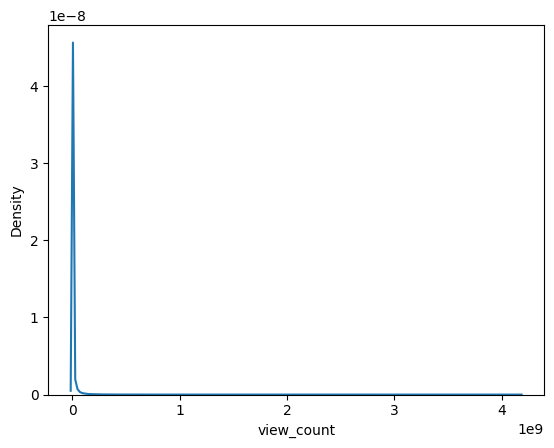

In [655]:
sns.kdeplot(x=final_df['view_count'])

<Axes: xlabel='view_count', ylabel='Density'>

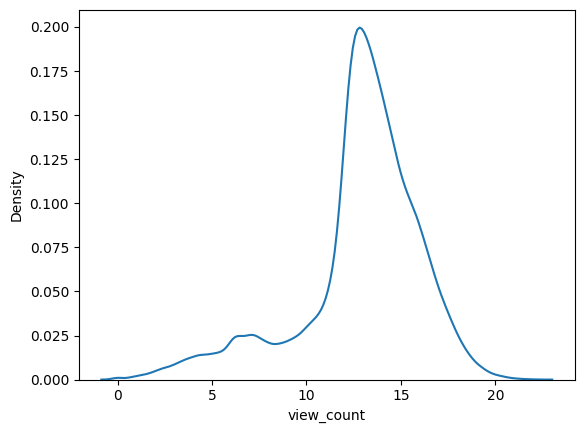

In [656]:
sns.kdeplot(x=final_df_3['view_count'])

In [666]:
final_df_4.shape

(180627, 31)